In [1]:
from google.colab import files

# ouvre une boîte de dialogue pour choisir ton fichier
uploaded = files.upload()


Saving phishing_email.csv to phishing_email (1).csv


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, Bidirectional


data = pd.read_csv("phishing_email.csv")
data.head(1)

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0


In [3]:
data.groupby('label').describe()

text_combined                                                            \
              count unique                                                top   
label                                                                           
0             39595  39233  alp presentation hi vince take care invitation...   
1             42891  42845  charity sees need cost dear friend read want f...   

            
      freq  
label       
0        2  
1        3

In [4]:
texts = data['text_combined'].astype(str)   # retourne Un objet pandas.Series
labels = data['label'].values


In [5]:
texts

,text_combined
0,hpl nom may 25 2001 see attached file hplno 52...
1,nom actual vols 24 th forwarded sabrae zajac h...
2,enron actuals march 30 april 1 201 estimated a...
3,hpl nom may 30 2001 see attached file hplno 53...
4,hpl nom june 1 2001 see attached file hplno 60...
...,...
82481,info advantageapartmentscom infoadvantageapart...
82482,monkeyorg helpdeskmonkeyorg monkeyorg hi josep...
82483,help center infohelpcentercoza_infohelpcenterc...
82484,metamask infosofamekarcom verify metamask wall...


In [6]:
labels

array([0, 0, 0, ..., 1, 1, 1])

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels #random_state garantit que : le découpage train / test est toujours le même - les résultats sont reproductibles utile pour pour : comparer des modèles
)

In [8]:
X_train

,text_combined
16517,path 15 path 15 n flows near limit beep put sp...
47803,daily top 10 duktengf2002apostcstatealus daily...
62032,monte gallagher hanshurtymcclainreadwritewebco...
39459,daily top 10 anirtretravenindustriescom daily ...
74114,guardian rssfeedsspamassassintaintorg url http...
...,...
75105,jim whitehead ejwcseucscedu around world growi...
53222,laurence blevins psolgaticushavistarcom useful...
24378,get rid premature ejaculation last longer incr...
48189,user21gvcceaschallengecc signature generated p...


In [9]:
y_train

array([0, 1, 1, ..., 1, 0, 1])

In [10]:
lengths = texts.apply(lambda x: len(x.split()))
lengths.describe()


,text_combined
count,82486.000000
mean,160.627222
std,543.720722
min,0.000000
25%,39.000000
50%,79.000000
75%,183.000000
max,107710.000000


In [11]:
from collections import Counter

all_words = " ".join(texts).split()
word_freq = Counter(all_words)

total_words = sum(word_freq.values())

top_30k = sum([freq for _, freq in word_freq.most_common(30000)])

print(top_30k / total_words)


0.8929249163194648


In [12]:
top_70k = sum([freq for _, freq in word_freq.most_common(70000)])

print(top_70k / total_words)


0.9303632432234975


In [13]:
VOCAB_SIZE = 70000
MAX_LEN = 250

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')


In [14]:
X_train_seq

[[1204,
  139,
  1204,
  139,
  195,
  5539,
  1513,
  1326,
  23281,
  363,
  2685,
  2179,
  2003,
  37697,
  494,
  23281,
  4703,
  96,
  7161,
  2408,
  96,
  2802,
  586,
  311,
  87,
  166,
  812,
  4066,
  8,
  106,
  332,
  15,
  1003,
  105,
  1626,
  2691,
  720,
  2091,
  33,
  165,
  1043,
  7468,
  2996,
  288,
  3889,
  20,
  143,
  4446,
  570,
  105,
  1626,
  24,
  165,
  5789,
  515,
  570],
 [70,
  23,
  6,
  1,
  70,
  23,
  6,
  72,
  23,
  277,
  263,
  5,
  3,
  2,
  715,
  55,
  622,
  23,
  6,
  277,
  3,
  696,
  928,
  1413,
  2258,
  1680,
  1597,
  10,
  838,
  2045,
  1482,
  2250,
  2214,
  1543,
  2259,
  2180,
  9,
  2082,
  225,
  2176,
  2260,
  13,
  2226,
  601,
  1750,
  2130,
  2261,
  27,
  2197,
  2233,
  1289,
  2262,
  22,
  281,
  883,
  1928,
  2116,
  2263,
  42,
  147,
  985,
  1152,
  691,
  2264,
  50,
  682,
  1784,
  740,
  2265,
  48,
  740,
  2266,
  682,
  2267,
  66,
  822,
  571,
  1237,
  267,
  94,
  2268,
  6,
  2215,
  2203,


In [15]:
len(X_train_seq)

65988

In [16]:
X_train_pad #we put the mails all the same length

array([[ 1204,   139,  1204, ...,     0,     0,     0],
       [   70,    23,     6, ...,     0,     0,     0],
       [ 8606, 15784,     1, ...,     0,     0,     0],
       ...,
       [   19,  3686,  7961, ...,     0,     0,     0],
       [12339,   771,  2005, ...,     0,     0,     0],
       [ 9141, 18511,     1, ...,     0,     0,     0]], dtype=int32)

In [17]:
EMBEDDING_DIM = 128

model = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM),
    Bidirectional(GRU(64, return_sequences=False)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])


In [19]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=6,
    batch_size=32,
    validation_split=0.1
)


Epoch 1/6
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 57s 27ms/step - accuracy: 0.9242 - loss: 0.1643 - precision: 0.9101 - recall: 0.9589 - val_accuracy: 0.9785 - val_loss: 0.0699 - val_precision: 0.9702 - val_recall: 0.9893
Epoch 2/6
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9936 - loss: 0.0211 - precision: 0.9935 - recall: 0.9942 - val_accuracy: 0.9864 - val_loss: 0.0448 - val_precision: 0.9853 - val_recall: 0.9887
Epoch 3/6
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.9986 - loss: 0.0056 - precision: 0.9984 - recall: 0.9988 - val_accuracy: 0.9845 - val_loss: 0.0519 - val_precision: 0.9835 - val_recall: 0.9870
Epoch 4/6
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 51s 28ms/step - accuracy: 0.9985 - loss: 0.0055 - precision: 0.9984 - recall: 0.9987 - val_accuracy: 0.9889 - val_loss: 0.0567 - val_precision: 0.9862 - val_recall: 0.9928
Epoch 5/6
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 59s 32ms/step - accuracy: 0.9995 - loss: 0.0018 - precision: 0.9996 - recall: 0.9994 - val_accuracy: 0.9889

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',   # or your original loss
    metrics=['accuracy']
)

In [ ]:
model.evaluate(X_test_pad, y_test)

In [20]:
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)


516/516 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step


In [21]:
y_pred_prob

array([[9.9999976e-01],
       [9.9857311e-07],
       [9.9986148e-01],
       ...,
       [9.9999475e-01],
       [3.2919232e-07],
       [1.0561896e-09]], dtype=float32)

In [22]:
y_pred

array([[1],
       [0],
       [1],
       ...,
       [1],
       [0],
       [0]])

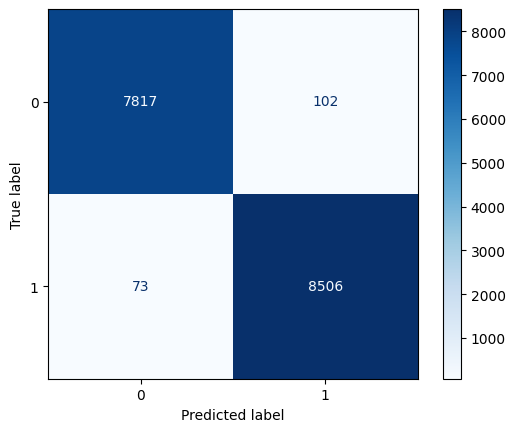

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.show()

In [26]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 128)       │     8,960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,034,625 (34.46 MB)

 Trainable params: 9,034,625 (34.46 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [29]:
results = model.evaluate(X_test_pad, y_test)

print("Loss:", results[0])
print("Accuracy:", results[1])

516/516 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9899 - loss: 0.0497
Loss: 0.05117939040064812
Accuracy: 0.9893926382064819


In [30]:
model.save("RNN_model_phishing_detection.h5")

In [31]:
from google.colab import files
files.download("RNN_model_phishing_detection.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
import json

tokenizer_json = tokenizer.to_json()

with open("tokenizer.json", "w") as f:
    f.write(tokenizer_json)

In [34]:
files.download("tokenizer.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))

NameError: name 'y_test' is not defined